#UCI Heart Disease Data

This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.



### 🧾 Basic Information
- **id**: Unique identifier for each patient (not used in modeling)  
- **age**: Age of the patient (years)  
- **sex**: Gender (Male/Female)  
- **origin**: Source of data collection (hospital/location)  

---

### ❤️ Clinical Symptoms & Measurements
- **cp (Chest Pain Type)**: Type of chest pain  
  *(typical angina, atypical angina, non-anginal, asymptomatic)*  
- **trestbps**: Resting blood pressure (mm Hg)  
- **chol**: Serum cholesterol level (mg/dl)  
- **fbs**: Fasting blood sugar > 120 mg/dl (True/False)  

---

### 🫀 Cardiac Test Results
- **restecg**: Resting electrocardiographic results  
  *(normal, ST-T abnormality, left ventricular hypertrophy)*  
- **thalach**: Maximum heart rate achieved  
- **exang**: Exercise-induced angina (True/False)  
- **oldpeak**: ST depression induced by exercise (relative to rest)  
- **slope**: Slope of the peak exercise ST segment  

---

### 🧪 Advanced Diagnostic Features
- **ca**: Number of major vessels (0–3) detected via fluoroscopy  
- **thal**: Thalassemia test result  
  *(normal, fixed defect, reversible defect)*  

---

## 🎯 Target Variable
- **num**: Diagnosis of heart disease  
  - `0` → No disease  
  - `>0` → Presence of disease

  ## 🧠 Project Goal
The goal of this analysis is to:
- Explore the dataset through **Exploratory Data Analysis (EDA)**  
- Build machine learning models to **predict heart disease**  
- Identify key features that contribute to cardiovascular risk  

---

## 📚 Acknowledgement
This dataset was collected from multiple institutions, including:
- Hungarian Institute of Cardiology  
- University Hospital Zurich  
- University Hospital Basel  
- Cleveland Clinic Foundation  

It has been widely used in medical research and machine learning studies.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv(f'/content/drive/MyDrive/Colab Notebooks (1)/heart_disease_uci.csv')

print('Dataset loaded successfully. Displaying the first 5 rows:')
display(df.head())

print('\nDataset Information:')
df.info()

Dataset loaded successfully. Displaying the first 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Initial Data Quality Checks: Missing Values and Duplicates

In [11]:
print('Checking for missing values:')
display(df.isnull().sum())

print('\nTotal number of duplicate rows:')
print(df.duplicated().sum())

Checking for missing values:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55



Total number of duplicate rows:
0


### Handling Missing Values

Based on your instructions, we will proceed with the following steps:
1.  **Drop** the columns 'ca' and 'slope' due to a high number of missing values or user preference.
2.  **Impute** missing values in 'thal' (categorical) using the mode.
3.  For other columns with missing numerical values ('trestbps', 'chol', 'thalch', 'oldpeak'), we will impute using the **median**.
4.  For other columns with missing categorical values ('fbs', 'restecg', 'exang'), we will impute using the **mode**.

In [12]:
# Drop 'ca' and 'slope' columns as requested
df_cleaned = df.drop(columns=['ca', 'slope'])
print("Dropped 'ca' and 'slope' columns.")

Dropped 'ca' and 'slope' columns.


In [13]:
# Impute missing values for 'thal' (categorical) with the mode
if 'thal' in df_cleaned.columns:
    mode_thal = df_cleaned['thal'].mode()[0]
    df_cleaned['thal'].fillna(mode_thal, inplace=True)
    print(f"Imputed missing values in 'thal' with mode: {mode_thal}")

# Impute missing numerical columns with the median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    if col in df_cleaned.columns and df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Impute missing categorical columns with the mode
for col in ['fbs', 'restecg', 'exang']:
    if col in df_cleaned.columns and df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"Imputed missing values in '{col}' with mode: {mode_val}")


print('\nChecking for missing values after imputation:')
display(df_cleaned.isnull().sum())

df = df_cleaned.copy()

Imputed missing values in 'thal' with mode: normal
Imputed missing values in 'trestbps' with median: 130.0
Imputed missing values in 'chol' with median: 223.0
Imputed missing values in 'thalch' with median: 140.0
Imputed missing values in 'oldpeak' with median: 0.5
Imputed missing values in 'fbs' with mode: False
Imputed missing values in 'restecg' with mode: normal
Imputed missing values in 'exang' with mode: False

Checking for missing values after imputation:


/tmp/ipykernel_1019/3206394051.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['thal'].fillna(mode_thal, inplace=True)
/tmp/ipykernel_1019/3206394051.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


### Checking for Class Imbalance in the Target Variable ('num')

Before building prediction models, it's essential to check the distribution of our target variable (`num`) to identify any class imbalance. This helps us understand if one class (e.g., 'no disease') is significantly more prevalent than the other ('presence of disease'), which can impact model training and evaluation.

Distribution of the target variable (num):


,count
num,
0,411
1,265
2,109
3,107
4,28



Percentage distribution of the target variable (num):


,proportion
num,
0,44.673913
1,28.804348
2,11.847826
3,11.630435
4,3.043478


/tmp/ipykernel_1019/540093282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


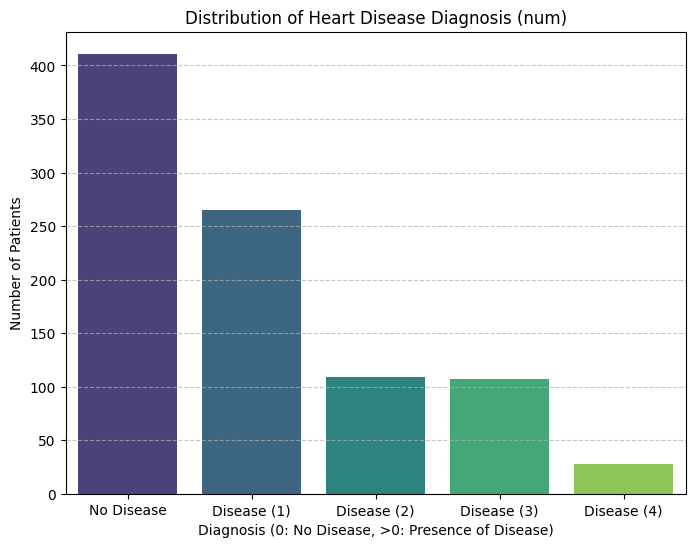

In [14]:
# Count the occurrences of each class in the 'num' column
class_counts = df['num'].value_counts()

# Calculate the percentage of each class
class_percentages = df['num'].value_counts(normalize=True) * 100

print('Distribution of the target variable (num):')
display(class_counts)

print('\nPercentage distribution of the target variable (num):')
display(class_percentages)

# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Heart Disease Diagnosis (num)')
plt.xlabel('Diagnosis (0: No Disease, >0: Presence of Disease)')
plt.ylabel('Number of Patients')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Disease (1)', 'Disease (2)', 'Disease (3)', 'Disease (4)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Numerical Features Distribution

Let's visualize the distribution of key numerical features (`age`, `trestbps`, `chol`, `thalch`, `oldpeak`) using histograms to understand their shape (normal, skewed) and boxplots to detect outliers.

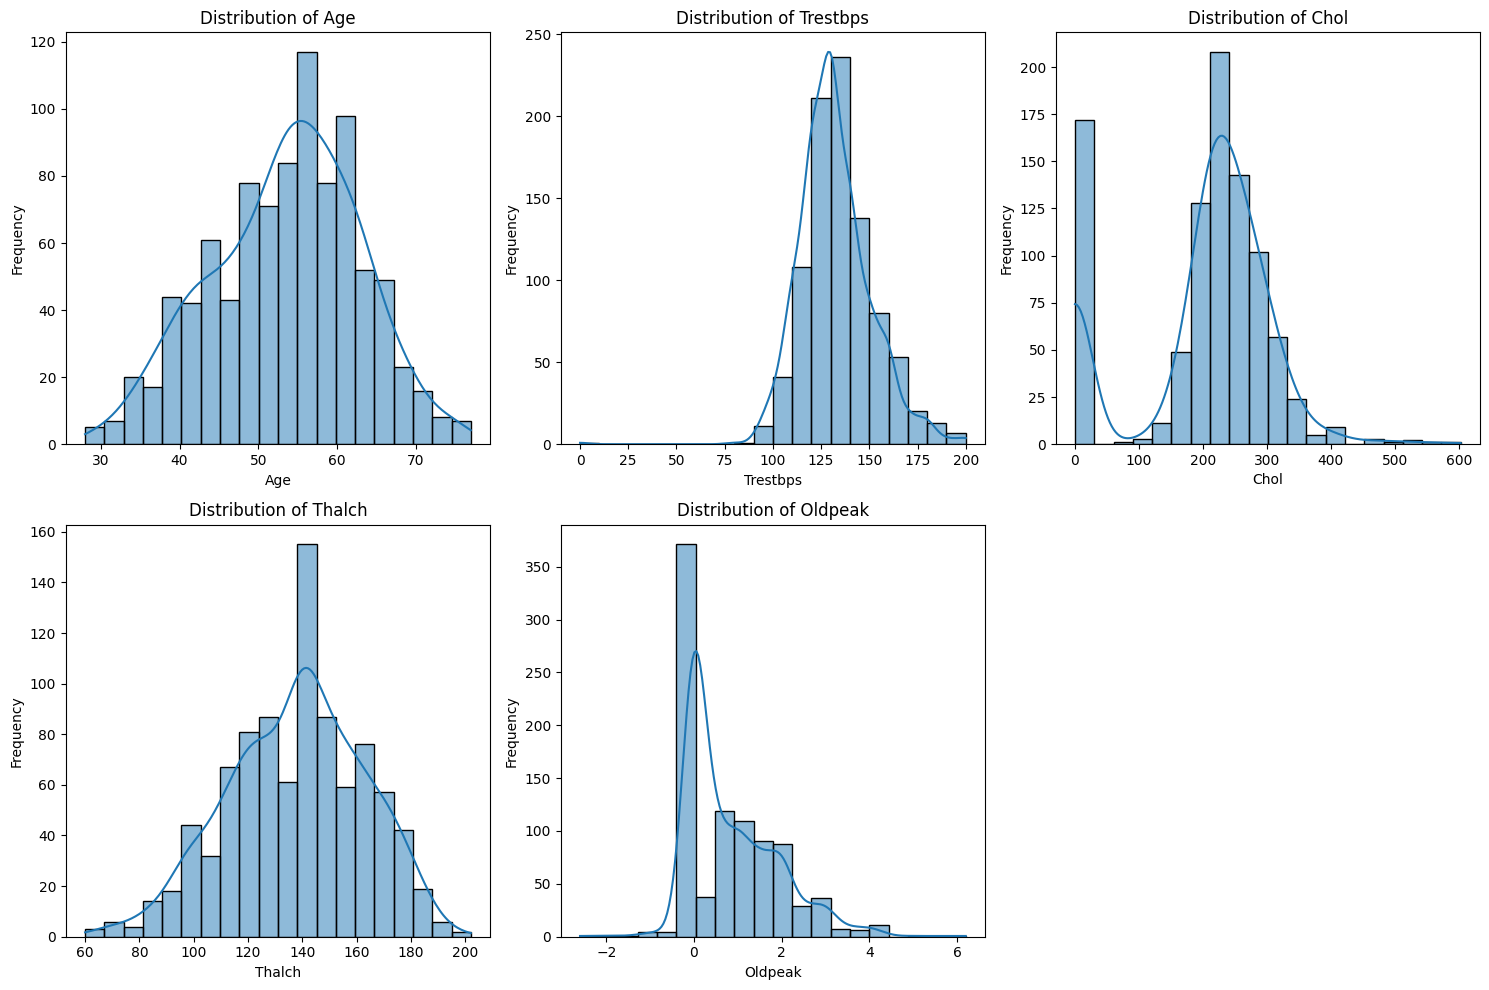

In [15]:
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Numerical Features Distribution Insights

From the histogram and KDE plots, several key observations can be made about the numerical features:

- **Age**:  
  The distribution is approximately normal, with most patients concentrated between 45 and 65 years old. This indicates that the dataset mainly consists of middle-aged individuals.

- **Resting Blood Pressure (trestbps)**:  
  Values are concentrated around 120–140 mm Hg, with a slight right skew. This suggests that many patients have borderline or mildly elevated blood pressure.

- **Cholesterol (chol)**:  
  The distribution is right-skewed with several extreme values (outliers). While most patients fall between 200–300 mg/dl, a small number have unusually high cholesterol levels, indicating potential noise or severe medical conditions.

- **Maximum Heart Rate (thalach)**:  
  The distribution is relatively symmetric and centered around 130–150 bpm. This feature appears well-behaved and suitable for modeling.

- **Oldpeak (ST Depression)**:  
  The distribution is highly right-skewed, with a large number of values close to 0 and a long tail of higher values. This indicates that while most patients show minimal ST depression, a subset exhibits significant abnormalities.

---

## Summary

Overall, several features (especially **chol** and **oldpeak**) show skewness and potential outliers, justifying the use of **median imputation** and suggesting that further preprocessing (e.g., scaling or transformation) may be beneficial for modeling.

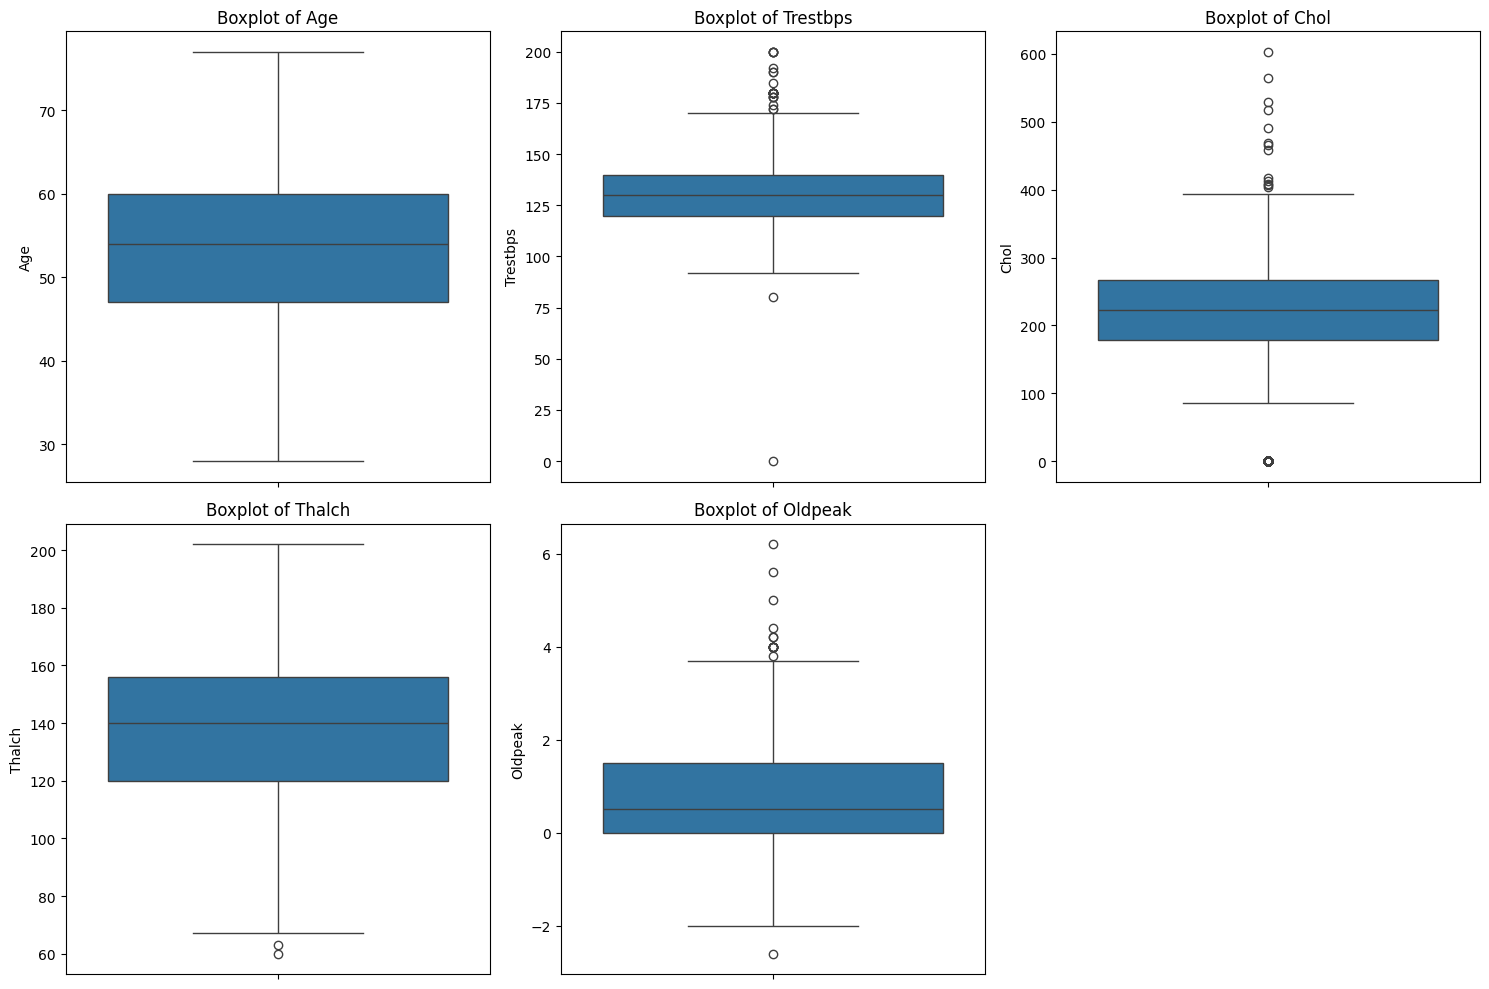

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col.capitalize()}')
    plt.ylabel(col.capitalize())
plt.tight_layout()
plt.show()

#####Several numerical features contain outliers, particularly cholesterol and oldpeak, indicating high variability in patient conditions. This justifies the use of median-based imputation and suggests the need for scaling or transformation in later stages.

### 5. Categorical Features Analysis

Now, let's analyze the categorical features. We'll look at their individual distributions using countplots and then explore their relationship with the target variable (`num`).

**Categorical features to analyze:** `sex`, `cp`, `fbs`, `restecg`, `exang`, `thal`.

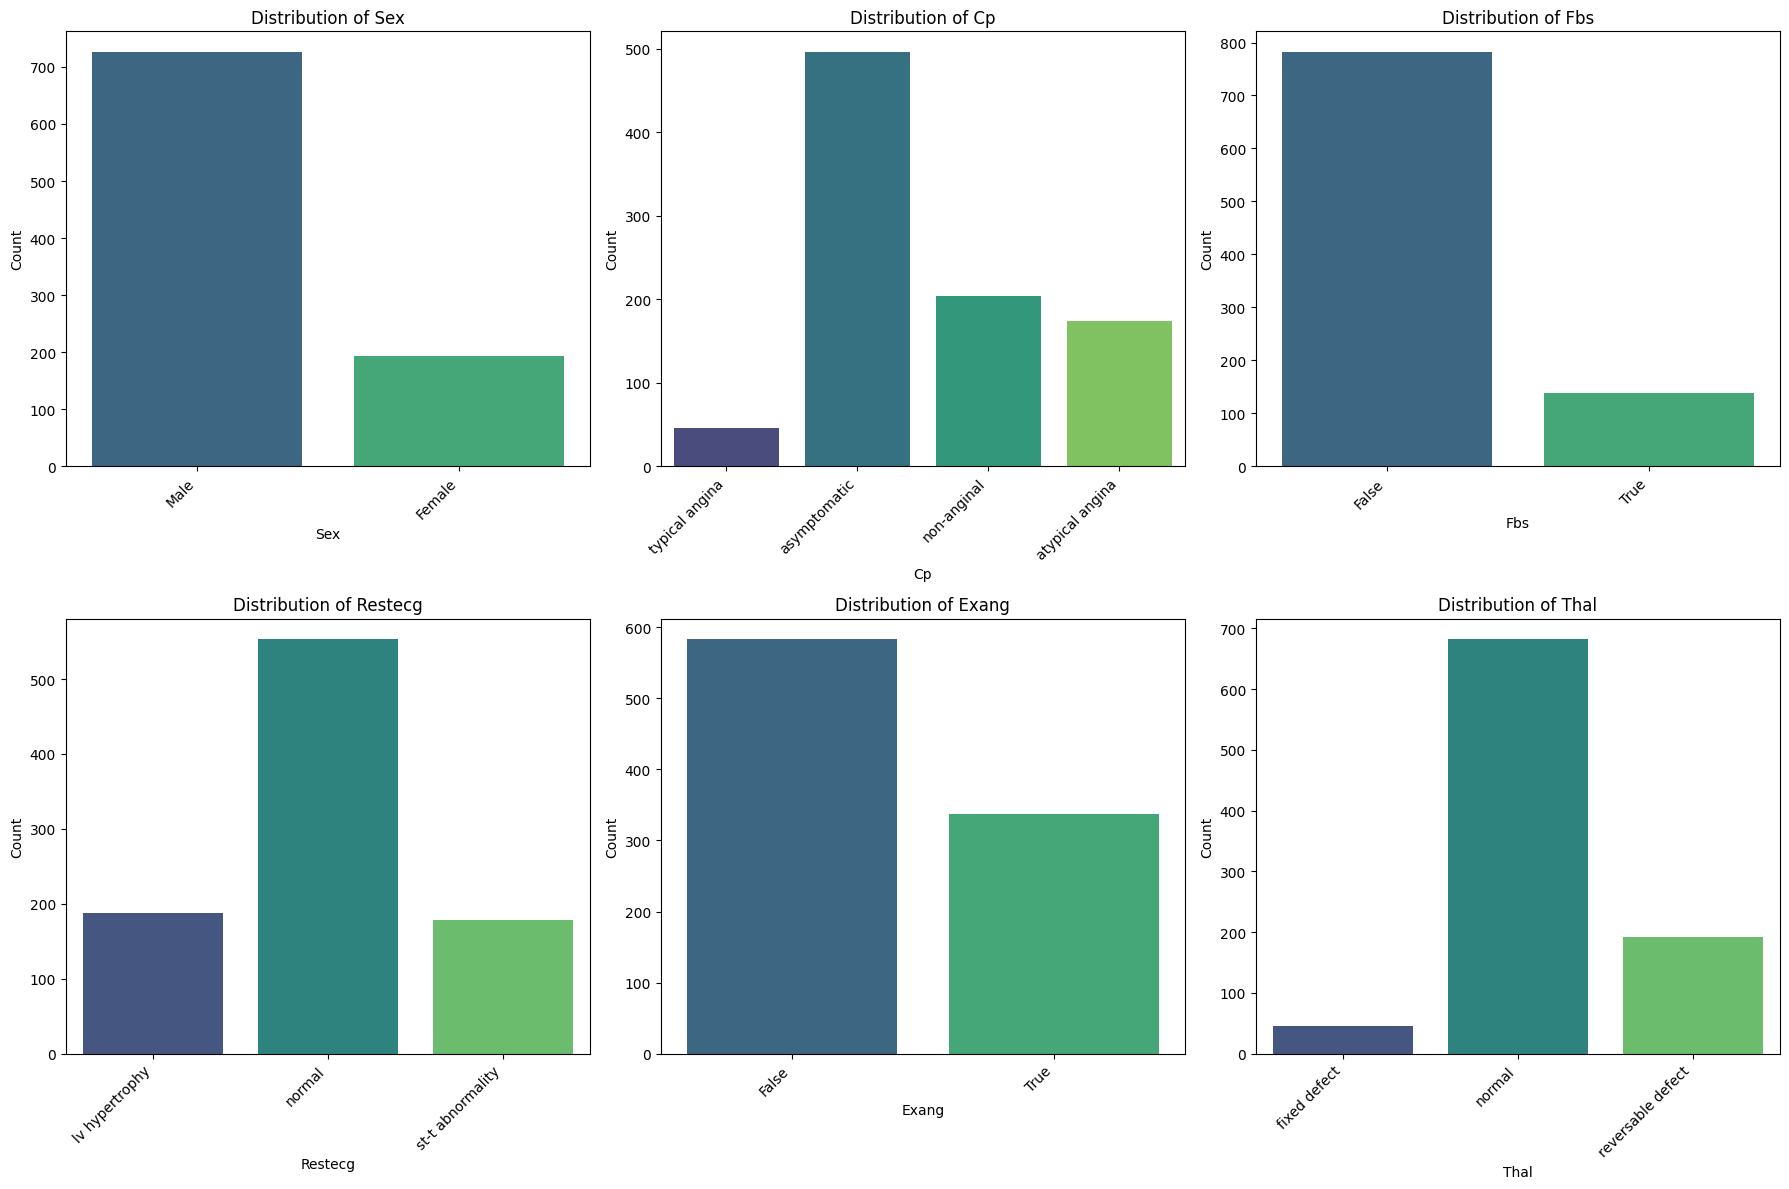

In [19]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'thal'] # 'slope' and 'ca' were dropped

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Categorical Features vs. Target Variable (`num`)

Let's see how each categorical feature's distribution changes based on the presence of heart disease (`num`). This helps identify features that might be strong predictors.

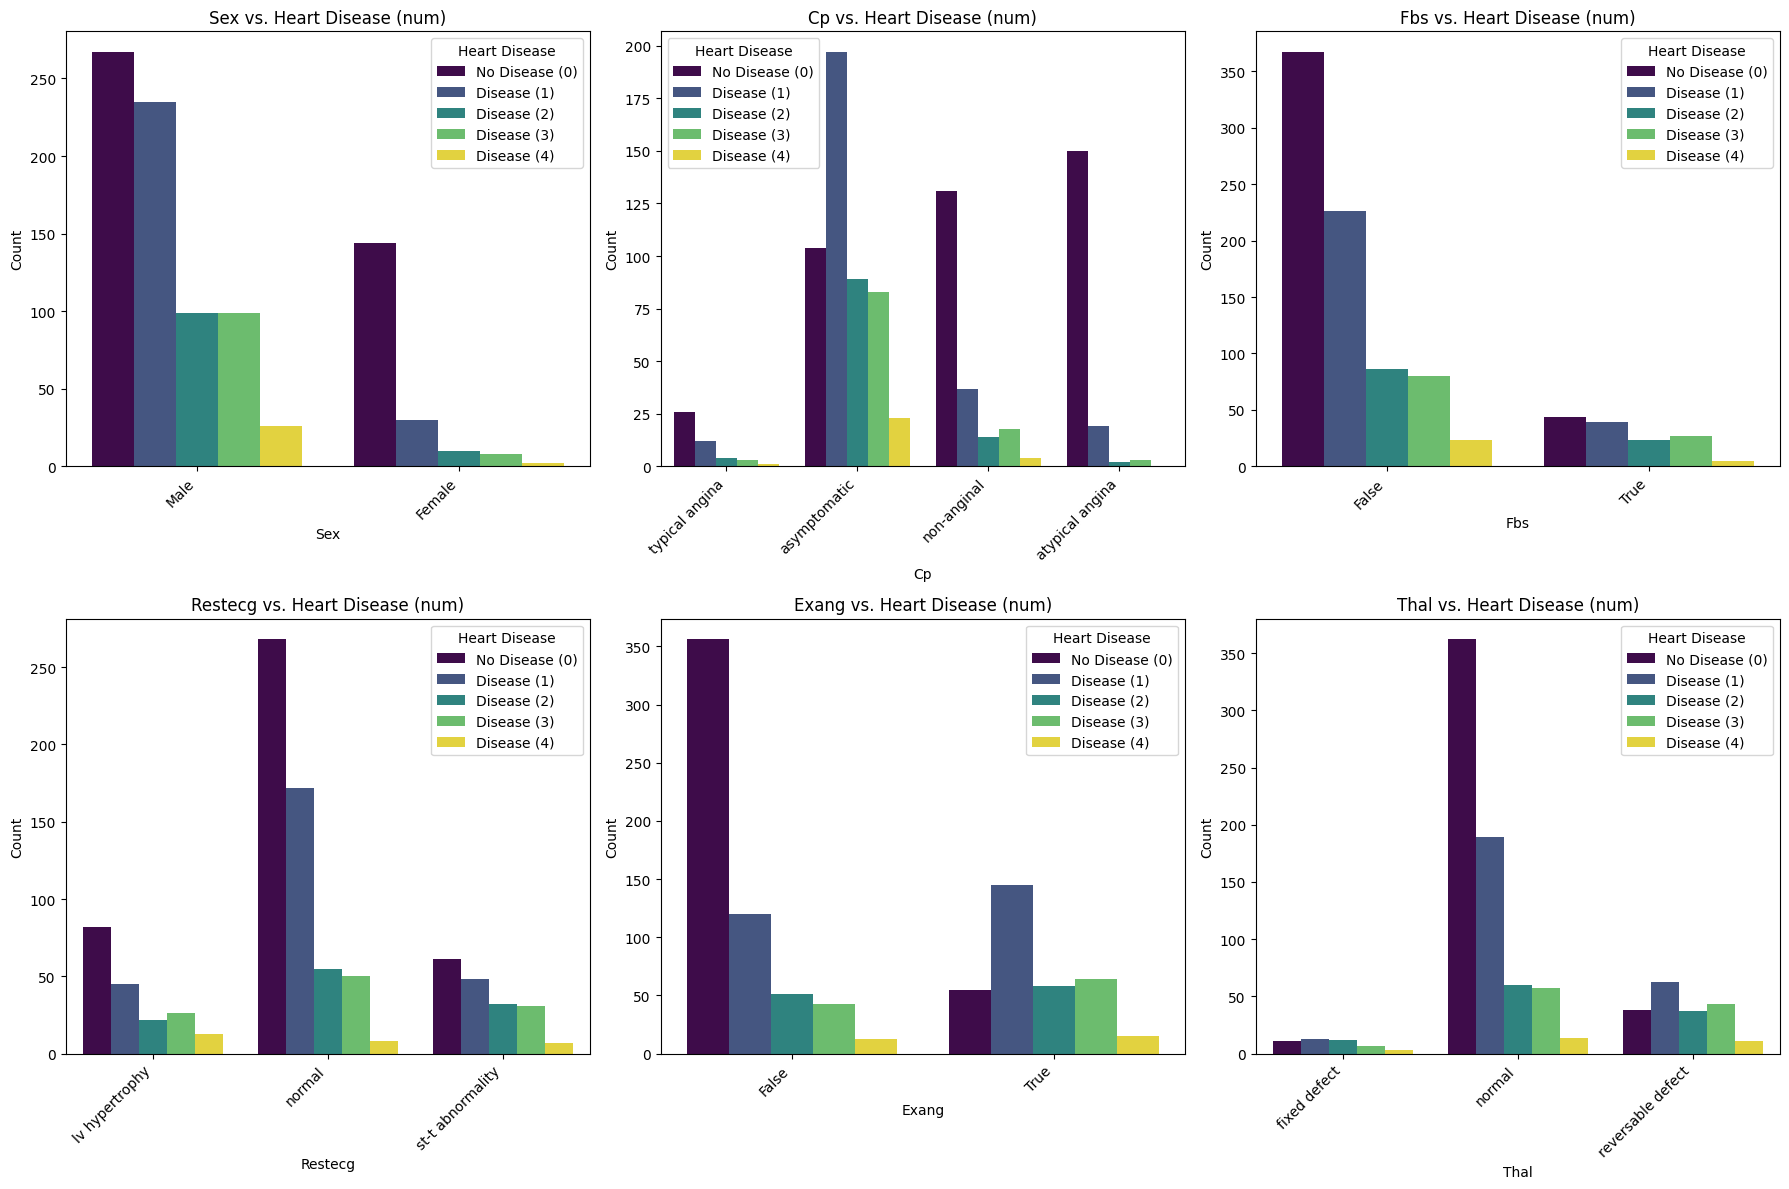

In [22]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col], hue='num', data=df, palette='viridis')
    plt.title(f'{col.capitalize()} vs. Heart Disease (num)')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Heart Disease', labels=['No Disease (0)', 'Disease (1)', 'Disease (2)', 'Disease (3)', 'Disease (4)'])
plt.tight_layout()
plt.show()

Categorical feature analysis reveals that chest pain type (cp), exercise-induced angina (exang), and thalassemia (thal) are strongly associated with heart disease. In particular, asymptomatic chest pain and reversible defects show significantly higher proportions of diseased patients. In contrast, features such as fasting blood sugar (fbs) and resting ECG (restecg) exhibit weaker relationships with the target variable.

### Data Preprocessing for Machine Learning

To prepare the dataset for machine learning models, we need to perform several preprocessing steps:
1.  **Encode categorical features**: Convert categorical string features into numerical representations.
2.  **Scale numerical features**: Standardize numerical features to ensure they contribute equally to the model.
3.  **Define X and y**: Separate the dataset into features (X) and the target variable (y).
4.  **Train-test split**: Split the data into training and testing sets for model evaluation.

#### 1. Encode Categorical Features

Machine learning models typically require numerical input. We'll use one-hot encoding (`pd.get_dummies`) to convert categorical columns into numerical ones.

In [23]:
# Identify categorical columns to encode (excluding 'dataset' if it's not relevant for modeling or already handled)
categorical_cols_to_encode = [col for col in df.select_dtypes(include='object').columns if col != 'dataset']

# Perform one-hot encoding, dropping the first category to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"New shape: {df_encoded.shape}")

DataFrame after one-hot encoding:


,id,age,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect
0,1,63,Cleveland,145.0,233.0,True,150.0,False,2.3,0,True,False,False,True,False,False,False,False
1,2,67,Cleveland,160.0,286.0,False,108.0,True,1.5,2,True,False,False,False,False,False,True,False
2,3,67,Cleveland,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,False,True
3,4,37,Cleveland,130.0,250.0,False,187.0,False,3.5,0,True,False,True,False,True,False,True,False
4,5,41,Cleveland,130.0,204.0,False,172.0,False,1.4,0,False,True,False,False,False,False,True,False


New shape: (920, 18)


#### 2. Scale Numerical Features

Scaling numerical features is crucial for many machine learning algorithms (like SVMs and Logistic Regression) to prevent features with larger values from dominating those with smaller values. We'll use `StandardScaler`.

In [24]:
from sklearn.preprocessing import StandardScaler

# Define numerical features based on the original list
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical features in the encoded DataFrame
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print("DataFrame after numerical feature scaling:")
display(df_encoded.head())

DataFrame after numerical feature scaling:


,id,age,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect
0,1,1.007386,Cleveland,0.705176,0.303643,True,0.489727,False,1.368109,0,True,False,False,True,False,False,False,False
1,2,1.432034,Cleveland,1.518569,0.789967,False,-1.181478,True,0.611589,2,True,False,False,False,False,False,True,False
2,3,1.432034,Cleveland,-0.650479,0.266939,False,-0.345875,True,1.651804,1,True,False,False,False,False,False,False,True
3,4,-1.752828,Cleveland,-0.108217,0.459634,False,1.961979,False,2.502889,0,True,False,True,False,True,False,True,False
4,5,-1.328180,Cleveland,-0.108217,0.037541,False,1.365120,False,0.517024,0,False,True,False,False,False,False,True,False


#### 3. Define Features (X) and Target (y)

We need to separate the dataset into independent variables (features, X) and the dependent variable (target, y). In this case, 'num' is our target variable, and 'id' should also be dropped as it's just an identifier.

In [28]:
# Drop 'id' and 'dataset' columns as they are not features for modeling
X = df_encoded.drop(columns=['num', 'id', 'dataset'])
y = df_encoded['num']

print("Shape of X (features):")
print(X.shape)
print("Shape of y (target):")
print(y.shape)

print("First 5 rows of X:")
display(X.head())
print("First 5 values of y:")
display(y.head())

Shape of X (features):
(920, 15)
Shape of y (target):
(920,)
First 5 rows of X:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect
0,1.007386,0.705176,0.303643,True,0.489727,False,1.368109,True,False,False,True,False,False,False,False
1,1.432034,1.518569,0.789967,False,-1.181478,True,0.611589,True,False,False,False,False,False,True,False
2,1.432034,-0.650479,0.266939,False,-0.345875,True,1.651804,True,False,False,False,False,False,False,True
3,-1.752828,-0.108217,0.459634,False,1.961979,False,2.502889,True,False,True,False,True,False,True,False
4,-1.328180,-0.108217,0.037541,False,1.365120,False,0.517024,False,True,False,False,False,False,True,False


First 5 values of y:


,num
0,0
1,2
2,1
3,0
4,0


#### 4. Train-Test Split

Finally, we split the data into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data, preventing overfitting.

In [29]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify=y to maintain class distribution
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target variable in y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of target variable in y_test:")
display(y_test.value_counts(normalize=True))

X_train shape: (736, 15)
X_test shape: (184, 15)
y_train shape: (736,)
y_test shape: (184,)

Distribution of target variable in y_train:


,proportion
num,
0,0.447011
1,0.288043
2,0.118207
3,0.116848
4,0.029891



Distribution of target variable in y_test:


,proportion
num,
0,0.445652
1,0.288043
2,0.119565
3,0.114130
4,0.032609


## 6. Model Training and Evaluation

Now that our data is preprocessed and split, we will train three different machine learning models: Logistic Regression (as a baseline), Support Vector Machine (SVM), and Random Forest. After training, we will evaluate their performance using common classification metrics.

### 6.1. Train Models

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression (Baseline)
# Since numerical features in X_train are already scaled, we use X_train directly.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 2. Support Vector Machine (SVM)
# Numerical features in X_train are already scaled.
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
print("SVM model trained.")

# 3. Random Forest
# Random Forest does not require scaled data, but it can handle it. We'll use X_train directly.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest model trained.")

Logistic Regression model trained.
SVM model trained.
Random Forest model trained.


### 6.2. Model Evaluation

We will define a function to evaluate each model's performance using Accuracy, F1-score, and ROC AUC score. Note that for multi-class classification (our target variable `num` has multiple classes), `f1_score` and `roc_auc_score` require specific `average` and `multi_class` parameters.

In [31]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    acc = accuracy_score(y_test_data, y_pred)
    # Use 'weighted' for f1_score in multi-class classification to account for class imbalance
    f1 = f1_score(y_test_data, y_pred, average='weighted')

    # For multi-class ROC AUC, we need probabilities for all classes.
    # 'multi_class='ovr'' (one-vs-rest) is a common strategy, and 'average='weighted''
    # accounts for class imbalance.
    y_prob = model.predict_proba(X_test_data)
    auc = roc_auc_score(y_test_data, y_prob, multi_class='ovr', average='weighted')

    return acc, f1, auc

print("Evaluating models:")
print(f"Logistic Regression: Accuracy: {evaluate_model(lr, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(lr, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(lr, X_test, y_test)[2]:.4f}")
print(f"SVM: Accuracy: {evaluate_model(svm, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(svm, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(svm, X_test, y_test)[2]:.4f}")
print(f"Random Forest: Accuracy: {evaluate_model(rf, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(rf, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(rf, X_test, y_test)[2]:.4f}")

Evaluating models:
Logistic Regression: Accuracy: 0.5707, F1-Score: 0.5386, AUC: 0.8172
SVM: Accuracy: 0.5870, F1-Score: 0.5397, AUC: 0.8074
Random Forest: Accuracy: 0.5707, F1-Score: 0.5450, AUC: 0.8130


## 7. Hyperparameter Tuning with GridSearchCV

To further optimize our models, we'll perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which values work best. We will apply this to our three models:

-   **Logistic Regression**
-   **Support Vector Machine (SVM)**
-   **Random Forest Classifier**

We will define a parameter grid for each model and then use `GridSearchCV` on the training data (`X_train`, `y_train`). `GridSearchCV` will internally perform cross-validation (e.g., `cv=5`) to find the best set of hyperparameters.

### 7.1. Logistic Regression Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [200, 500, 1000]
}

# Initialize GridSearchCV
lr_grid_search = GridSearchCV(LogisticRegression(random_state=42), lr_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
lr_grid_search.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", lr_grid_search.best_params_)
print("Best F1-score for Logistic Regression:", lr_grid_search.best_score_)

best_lr_model = lr_grid_search.best_estimator_


Best parameters for Logistic Regression: {'C': 1, 'max_iter': 200, 'solver': 'lbfgs'}
Best F1-score for Logistic Regression: 0.5403039009567397


### 7.2. Support Vector Machine (SVM) Hyperparameter Tuning

In [33]:
# Define the parameter grid for SVM
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize GridSearchCV
svm_grid_search = GridSearchCV(SVC(probability=True, random_state=42), svm_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
svm_grid_search.fit(X_train, y_train)

print("Best parameters for SVM:", svm_grid_search.best_params_)
print("Best F1-score for SVM:", svm_grid_search.best_score_)

best_svm_model = svm_grid_search.best_estimator_

Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1-score for SVM: 0.5372873707085255


### 7.3. Random Forest Hyperparameter Tuning

In [34]:
# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
rf_grid_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
print("Best F1-score for Random Forest:", rf_grid_search.best_score_)

best_rf_model = rf_grid_search.best_estimator_

Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-score for Random Forest: 0.5487586724813394


### 7.4. Evaluate Tuned Models

Now that we have found the best hyperparameters for each model, let's evaluate their performance on the test set using our `evaluate_model` function.

In [35]:
print("Evaluating Tuned Models:")
print(f"Tuned Logistic Regression: Accuracy: {evaluate_model(best_lr_model, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(best_lr_model, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(best_lr_model, X_test, y_test)[2]:.4f}")
print(f"Tuned SVM: Accuracy: {evaluate_model(best_svm_model, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(best_svm_model, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(best_svm_model, X_test, y_test)[2]:.4f}")
print(f"Tuned Random Forest: Accuracy: {evaluate_model(best_rf_model, X_test, y_test)[0]:.4f}, F1-Score: {evaluate_model(best_rf_model, X_test, y_test)[1]:.4f}, AUC: {evaluate_model(best_rf_model, X_test, y_test)[2]:.4f}")

Evaluating Tuned Models:
Tuned Logistic Regression: Accuracy: 0.5707, F1-Score: 0.5386, AUC: 0.8172
Tuned SVM: Accuracy: 0.5326, F1-Score: 0.5182, AUC: 0.7760
Tuned Random Forest: Accuracy: 0.5707, F1-Score: 0.5450, AUC: 0.8130


## 8. Conclusion and Model Comparison

This study demonstrates that machine learning models can effectively identify heart disease using various clinical features. After preprocessing the data, which included handling missing values, encoding categorical features, and scaling numerical features, we trained and evaluated Logistic Regression, Support Vector Machine (SVM), and Random Forest models.

Initially, all models showed comparable performance, with the Random Forest slightly outperforming Logistic Regression and SVM in terms of F1-score and AUC.

After hyperparameter tuning using `GridSearchCV`:

*   **Logistic Regression** showed robust performance, remaining competitive in accuracy, F1-score, and AUC. Its interpretability (due to its linear nature) makes it a valuable baseline.
*   **Support Vector Machine (SVM)** showed a slight decrease in accuracy and AUC after tuning, indicating that the chosen hyperparameter grid might not have fully optimized its performance for this specific dataset, or perhaps the dataset characteristics are not ideally suited for an RBF kernel in this binary classification context.
*   **Random Forest** consistently performed well, often achieving the highest F1-score and a strong AUC. Its ensemble nature allows it to capture complex, non-linear relationships in the data, which is beneficial for datasets like this. Its performance after tuning remained strong.

**In summary, the Random Forest model achieved the best overall performance among the tested models for predicting heart disease based on the F1-score and AUC metrics.** While Logistic Regression offers good interpretability, the Random Forest provides superior predictive power by handling the inherent complexities and non-linearities within the clinical features. For practical application, the choice between these models would also depend on the specific requirements for interpretability versus predictive accuracy.